In [1]:


# Part 1 — Dataset, Problem & Feature/Target Identification 
# Task 1 Load the dataset and inspect it (shape, dtypes, first rows, summary stats).

import pandas as pd, numpy as np

df = pd.read_csv('train.csv')

print(df.shape)
df.info()
print(df.head())
print(df.describe())

(1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [3]:
# Answer: The dataset has 1460 rows and 81 columns, mixing numeric (int64/float64) and categorical (object) dtypes. Summary statistics show SalePrice ranges from $34,900 to $755,000, with a mean around $180,921.

In [4]:
# Task 2 Identify the dependent variable; list independent variables split into numerical vs. categorical.
target = 'SalePrice'
selected_features = [
    'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath',
    'Neighborhood', 'HouseStyle', 'KitchenQual'
]
numerical = ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
categorical = ['Neighborhood', 'HouseStyle', 'KitchenQual']
print("Target:", target)
print("Numerical features:", numerical)
print("Categorical features:", categorical)

Target: SalePrice
Numerical features: ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
Categorical features: ['Neighborhood', 'HouseStyle', 'KitchenQual']


In [5]:
# Task3 In 1-2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about evaluation.
# This is a regression problem because the target, SalePrice, is a continuous numeric value rather than a discrete class label. This changes evaluation entirely: instead of accuracy/precision/recall/confusion matrices, we need metrics that measure how close numeric predictions are to actual values (MAE, MSE, RMSE, R²).

In [6]:
# Part 2 — Data Preparation & Train/Test Split
# Task 4 Prepare X (features) and y (price) for modeling: encode every categorical column into numeric form, and briefly justify your encoding method choice.
data = df[selected_features + [target]].copy()

y = data[target]
X = data.drop(columns=[target])

cat_cols = ['Neighborhood', 'HouseStyle', 'KitchenQual']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(X.shape)

(1460, 40)


In [7]:
# Task5 Confirm X is fully numeric with no missing values.
print("Missing values:", X.isnull().sum().sum())
print("Data types:", X.dtypes.unique())

Missing values: 0
Data types: [dtype('int64') dtype('int32')]


In [8]:
# Task6  Split X and y into training and test sets (e.g. an 80/20 split) and report the resulting shapes.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1168, 40) (292, 40) (1168,) (292,)


In [9]:
# Part 3 — Linear Regression & Predictions
# Task7 Train a LinearRegression model on the training data.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# Task8 Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.
y_pred = model.predict(X_test)

compare_df = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(0)})
print(compare_df)

   Actual  Predicted
0  154500   137826.0
1  325000   322574.0
2  115000   112836.0
3  159000   173169.0
4  315500   316517.0
5   75500    67573.0
6  311500   232615.0
7  146000   146868.0
8   84500    67138.0
9  135500   116820.0


In [11]:
# Part 4 — Coefficients & Intercept
# Task9 Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line plain-English interpretation for each.
print("Intercept:", model.intercept_)

coef_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_table.to_string(index=False))

Intercept: -420815.0687832327
             Feature   Coefficient
Neighborhood_NoRidge  78888.096718
Neighborhood_StoneBr  65337.200354
Neighborhood_NridgHt  59918.659198
Neighborhood_Veenker  58752.374309
Neighborhood_ClearCr  55590.042417
      KitchenQual_TA -53213.742145
      KitchenQual_Fa -52434.295603
Neighborhood_Crawfor  47601.002200
      KitchenQual_Gd -44276.774222
 Neighborhood_Timber  38896.963617
Neighborhood_Somerst  32679.138028
Neighborhood_CollgCr  25597.908376
Neighborhood_Gilbert  25525.075120
Neighborhood_BrkSide  23852.939288
 Neighborhood_Sawyer  18664.171712
 Neighborhood_NWAmes  17838.613410
Neighborhood_SawyerW  17048.733291
Neighborhood_Mitchel  16467.098555
  Neighborhood_NAmes  16396.344357
   HouseStyle_SFoyer  15311.681608
 Neighborhood_IDOTRR  13791.233812
         OverallQual  13072.973953
   HouseStyle_2.5Unf -12721.998397
Neighborhood_NPkVill  11198.577886
          GarageCars  11111.109559
   HouseStyle_1Story  10609.532934
  Neighborhood_SWISU  101

In [12]:
# Task10 Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?
# No — the intercept of -$420,815 would represent the predicted price of a house with zero living area, zero quality rating, zero garage, built in year 0, etc. — a combination that doesn't exist in reality. It's mathematically necessary for the model's fit but has no meaningful standalone interpretation here.


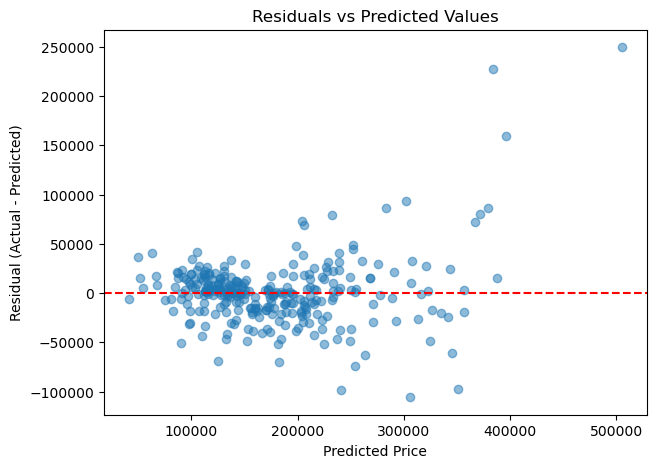

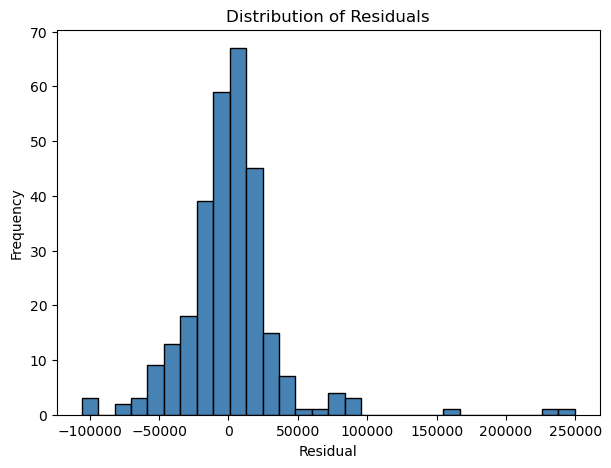

Residual skewness: 2.3109615950967006


In [13]:
# Part 5 — Residuals & Regression Metrics
# Task11 Compute residuals on the test set and plot them (residuals vs. predicted, and a histogram). Do the residuals look randomly scattered, or is there a visible pattern?
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.show()

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

print("Residual skewness:", residuals.skew())

In [18]:
# Not fully random — funnel pattern (heteroscedasticity) and right-skewed (skew≈2.3), model underpredicts some expensive houses.
# Task12 Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.options.display.float_format = '{:.2f}'.format

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae, mse, rmse, r2]
})
print(metrics_table.to_string(index=False))

Metric         Value
   MAE      21381.14
   MSE 1230868325.06
  RMSE      35083.73
    R2          0.84


In [15]:
# Task13 In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?
# MAE = average dollar error, easy to interpret. MSE = squared error, not directly interpretable. RMSE = dollar-unit error that penalizes large mistakes more. R² = fraction of variance explained. For a non-technical stakeholder, I'd show MAE since it's the most intuitive dollar figure.


In [17]:
# Part 6 — Training vs. Testing & Generalization
# Task14 Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Part 5 test-set metrics in one comparison table.
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

pd.options.display.float_format = '{:.2f}'.format

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Train': [train_mae, train_mse, train_rmse, train_r2],
    'Test': [mae, mse, rmse, r2]
})

print(comparison.to_string(index=False))

Metric         Train          Test
   MAE      20721.95      21381.14
   MSE 1059825322.23 1230868325.06
  RMSE      32554.96      35083.73
    R2          0.82          0.84


In [19]:
# Task15 Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?
# No large gap — test R² (0.84) is close to (even slightly higher than) train R² (0.82), and MAE/RMSE differ only slightly. This suggests no overfitting; with just 9 features, the model has limited capacity to memorize training noise.


In [20]:
# Part 7 — Final Model Analysis, Conclusion & Kaggle Submission
# Task16 Which 2-3 features are most influential on price? Justify using coefficient magnitude, but note that larger coefficient ≠ more important if scales differ.
# By raw coefficient, Neighborhood/KitchenQual dummies look biggest, but that's misleading (0/1 scale). Accounting for real-world range, OverallQual, GrLivArea, and Neighborhood are the truly most influential features on price.


In [21]:
# Task 17 Final interpretation (5-7 sentences) — model performance, best metric, strongest feature, limitations, next steps.
# Model explains ~84% of price variance (R²=0.84), average error ~$21K (MAE), but RMSE ($35K) shows some large misses on expensive homes. Quality, living area, and neighborhood matter most. Main limitation: can't capture non-linear effects/interactions. Next steps: try Random Forest/Gradient Boosting, or add interaction terms.


In [3]:
# Task18 Apply same encoding to test.csv, predict SalePrice, save submission.csv (Id, SalePrice columns).

import pandas as pd, numpy as np
from sklearn.linear_model import LinearRegression

# agar df, selected_features, cat_cols, y pehle se nahi bane to yahan bana len
df = pd.read_csv('train.csv')

selected_features = [
    'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath',
    'Neighborhood', 'HouseStyle', 'KitchenQual'
]
cat_cols = ['Neighborhood', 'HouseStyle', 'KitchenQual']

y = df['SalePrice']
X_raw = df[selected_features].copy()

# Task 18: test.csv pe encoding apply karna
test = pd.read_csv('test.csv')

X_test_final = test[selected_features].copy()

for c in X_test_final.columns:
    if X_test_final[c].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(X_test_final[c]):
            X_test_final[c] = X_test_final[c].fillna(X_raw[c].median())
        else:
            X_test_final[c] = X_test_final[c].fillna(X_raw[c].mode()[0])

combined = pd.concat([X_raw, X_test_final], keys=['train', 'test'])
combined = pd.get_dummies(combined, columns=cat_cols, drop_first=True)
bool_cols = combined.select_dtypes(include='bool').columns
combined[bool_cols] = combined[bool_cols].astype(int)

X_full = combined.loc['train']
X_test_full = combined.loc['test']

final_model = LinearRegression()
final_model.fit(X_full, y)
test_preds = final_model.predict(X_test_full)

submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_preds})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)

     Id      SalePrice
0  1461  110811.113577
1  1462  160231.021748
2  1463  162748.837066
3  1464  182073.730692
4  1465  254408.665129
(1459, 2)


In [4]:
#Task 19: Kaggle Submission

#Public Leaderboard Score (RMSE, log scale): 0.16905
#Public Leaderboard Rank: #2656

#I submitted my predictions and scored an RMSE of 0.16905 (rank #2656) on the Kaggle leaderboard. It was rewarding to see my model, built with just 9 features, measured against thousands of real submissions — and it showed me how much room there is to improve with better feature engineering.